# Celda 1 — Imports y configuración

In [ ]:
# ===== CELDA 1: Cargar CIFAR-10 =====
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

# Carga CIFAR-10 (descarga automática, sin SSL de Microsoft)
(ds_train, ds_val, ds_test), info = tfds.load(
    "cifar10",
    split=["train[:80%]", "train[80%:]", "test"],
    as_supervised=True,
    with_info=True
)

print(info)
print("Clases:", info.features['label'].names)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.0E81IH_3.0.2/cifar10-train.tfrecord*...:   0%|         …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.0E81IH_3.0.2/cifar10-test.tfrecord*...:   0%|          …

Dataset cifar10 downloaded and prepared to /root/tensorflow_datasets/cifar10/3.0.2. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='cifar10',
    full_name='cifar10/3.0.2',
    description="""
    The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images.
    """,
    homepage='https://www.cs.toronto.edu/~kriz/cifar.html',
    data_dir='/root/tensorflow_datasets/cifar10/3.0.2',
    file_format=tfrecord,
    download_size=162.17 MiB,
    dataset_size=132.40 MiB,
    features=FeaturesDict({
        'id': Text(shape=(), dtype=string),
        'image': Image(shape=(32, 32, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_examples=10000, num_shards=1>,
        'train': <SplitInfo nu

# Celda 2 — Cargar dataset

In [ ]:
# ===== CELDA 2: Preprocesamiento =====
IMG_SIZE = (32, 32)  # CIFAR-10 ya es 32x32
BATCH_SIZE = 64

def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

AUTOTUNE = tf.data.AUTOTUNE

ds_train_p = (ds_train
              .map(preprocess, num_parallel_calls=AUTOTUNE)
              .shuffle(5000)
              .batch(BATCH_SIZE)
              .prefetch(AUTOTUNE))

ds_val_p = (ds_val
            .map(preprocess, num_parallel_calls=AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

ds_test_p = (ds_test
             .map(preprocess, num_parallel_calls=AUTOTUNE)
             .batch(BATCH_SIZE)
             .prefetch(AUTOTUNE))

# Celda 3 — Preprocesamiento

In [ ]:
# ===== CELDA 3: Red Feedforward =====
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(32, 32, 3)),
    tf.keras.layers.Dense(512, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(10, activation="softmax")  # 10 clases
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,640,330 (6.26 MB)

 Trainable params: 1,640,330 (6.26 MB)

 Non-trainable params: 0 (0.00 B)

# Celda 4 — Modelo feedforward

In [ ]:
# ===== CELDA 4: Entrenar =====
history = model.fit(
    ds_train_p,
    validation_data=ds_val_p,
    epochs=8,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)]
)

Epoch 1/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 42ms/step - accuracy: 0.4034 - loss: 1.6434 - val_accuracy: 0.4367 - val_loss: 1.6089
Epoch 2/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.4052 - loss: 1.6435 - val_accuracy: 0.4395 - val_loss: 1.5971
Epoch 3/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 39ms/step - accuracy: 0.4052 - loss: 1.6437 - val_accuracy: 0.4391 - val_loss: 1.5909
Epoch 4/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 39ms/step - accuracy: 0.4097 - loss: 1.6379 - val_accuracy: 0.4413 - val_loss: 1.5719
Epoch 5/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 39ms/step - accuracy: 0.4112 - loss: 1.6319 - val_accuracy: 0.4333 - val_loss: 1.5757
Epoch 6/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 41ms/step - accuracy: 0.4077 - loss: 1.6357 - val_accuracy: 0.4408 - val_loss: 1.5811
Epoch 7/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.4101 - loss: 1.6324 - val_accuracy: 0.4385 - val_loss: 1.5985


# Celda 5 — Entrenamiento

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.4347 - loss: 1.5757
Test Accuracy: 0.4336


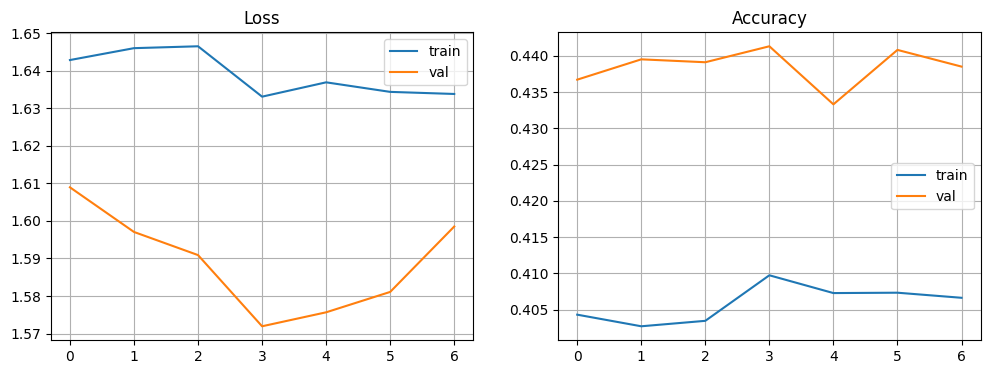

In [ ]:
# ===== CELDA 5: Evaluar =====
test_loss, test_acc = model.evaluate(ds_test_p)
print(f"Test Accuracy: {test_acc:.4f}")

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Celda 6 — Evaluación + gráficas

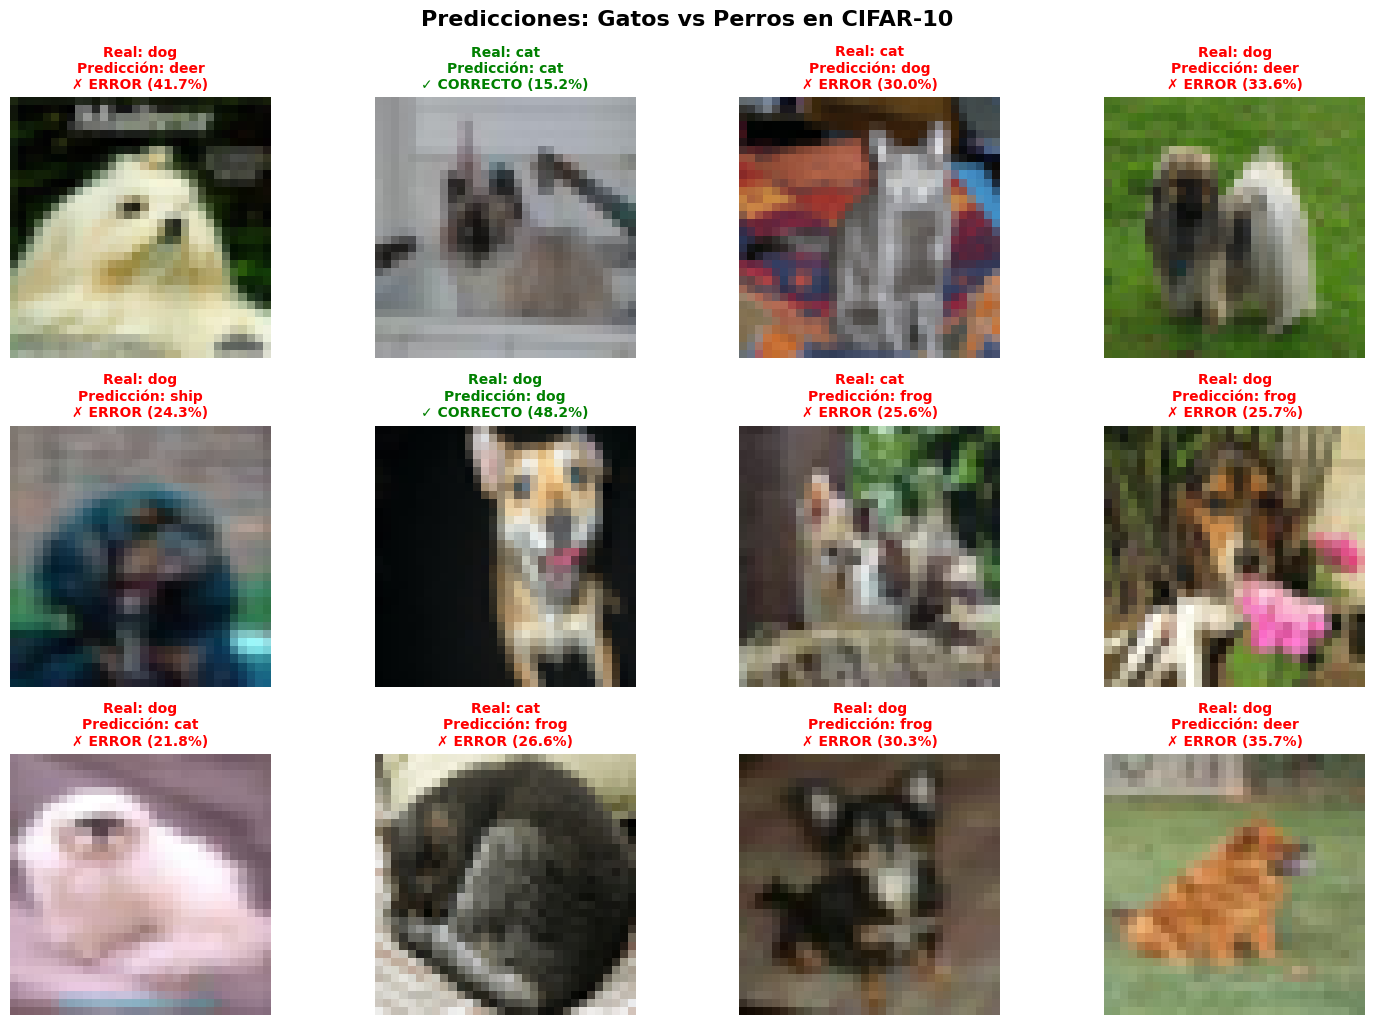


ESTADÍSTICAS DE GATOS Y PERROS:
Gatos: 1/4 correctos (25.0%)
Perros: 1/8 correctos (12.5%)
Total: 2/12 correctos


In [ ]:
# ===== CELDA 6: Visualizar predicciones de Gatos y Perros =====
import numpy as np

# Nombres de clases CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Índices de gatos y perros
CAT_IDX = 3
DOG_IDX = 5

# Tomar imágenes del conjunto de test
images_to_show = []
labels_to_show = []

for image, label in ds_test.take(10000):  # buscar en todo el test
    if label.numpy() in [CAT_IDX, DOG_IDX]:
        images_to_show.append(image.numpy())
        labels_to_show.append(label.numpy())
    if len(images_to_show) >= 12:  # mostrar 12 imágenes
        break

# Convertir a arrays
images_array = np.array(images_to_show) / 255.0
labels_array = np.array(labels_to_show)

# Hacer predicciones
predictions = model.predict(images_array, verbose=0)
predicted_classes = np.argmax(predictions, axis=1)

# Visualizar
fig, axes = plt.subplots(3, 4, figsize=(15, 10))
axes = axes.flatten()

for i in range(min(12, len(images_array))):
    axes[i].imshow(images_array[i])

    true_label = class_names[labels_array[i]]
    pred_label = class_names[predicted_classes[i]]
    confidence = predictions[i][predicted_classes[i]] * 100

    # Color verde si acertó, rojo si falló
    is_correct = (labels_array[i] == predicted_classes[i])
    color = 'green' if is_correct else 'red'
    status = '✓ CORRECTO' if is_correct else '✗ ERROR'

    title = f"Real: {true_label}\nPredicción: {pred_label}\n{status} ({confidence:.1f}%)"
    axes[i].set_title(title, color=color, fontweight='bold', fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.suptitle('Predicciones: Gatos vs Perros en CIFAR-10',
             fontsize=16, fontweight='bold', y=1.02)
plt.show()

# Estadísticas
cats_correct = sum((labels_array == CAT_IDX) & (predicted_classes == CAT_IDX))
cats_total = sum(labels_array == CAT_IDX)
dogs_correct = sum((labels_array == DOG_IDX) & (predicted_classes == DOG_IDX))
dogs_total = sum(labels_array == DOG_IDX)

print(f"\n{'='*50}")
print(f"ESTADÍSTICAS DE GATOS Y PERROS:")
print(f"{'='*50}")
print(f"Gatos: {cats_correct}/{cats_total} correctos ({cats_correct/cats_total*100:.1f}%)")
print(f"Perros: {dogs_correct}/{dogs_total} correctos ({dogs_correct/dogs_total*100:.1f}%)")
print(f"Total: {cats_correct + dogs_correct}/{cats_total + dogs_total} correctos")
